In [35]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

# **MY CODE**

In [36]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded")

Libraries loaded


In [37]:
# Load train and test
train = pd.read_csv(r"..\data\train.csv")
test = pd.read_csv(r'..\data\test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (2000, 8)
Test shape : (500, 7)


In [38]:
train.head(2)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


In [39]:
display(train.describe())
display(train.info())

,id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


None

In [40]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


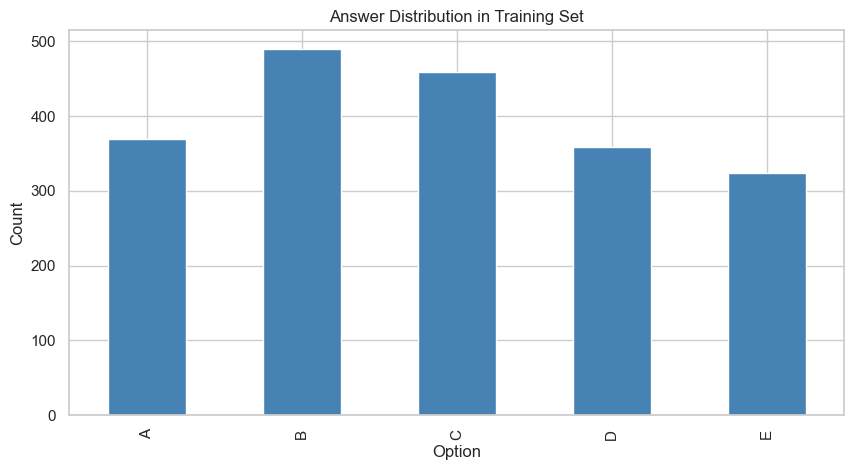

In [41]:
train['answer'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Answer Distribution in Training Set')
plt.xlabel('Option')
plt.ylabel('Count')
plt.show()

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [43]:
options = ['A', 'B', 'C', 'D', 'E']

def combine_prompt_option(row, option):
    return row['prompt'] + "  |  " + row[option]


# print(combine_prompt_option(train.iloc[0], 'A'))
# print("---")
# print(combine_prompt_option(train.iloc[0], 'B'))

def predict_top3(row):
    # Step 1: combine prompt with each option
    texts = [combine_prompt_option(row, opt) for opt in options]
    
    # Step 2: fit TF-IDF on all 5 combined texts
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    
    # Step 3: compute cosine similarity of each option against the first one (prompt+A)
    # Actually we compare prompt alone vs each option
    prompt_vec = vectorizer.transform([row['prompt']])
    scores = cosine_similarity(prompt_vec, tfidf_matrix).flatten()
    
    # Step 4: rank options by score descending, take top 3
    top3_indices = scores.argsort()[::-1][:3]
    top3_labels = [options[i] for i in top3_indices]
    
    return ' '.join(top3_labels)

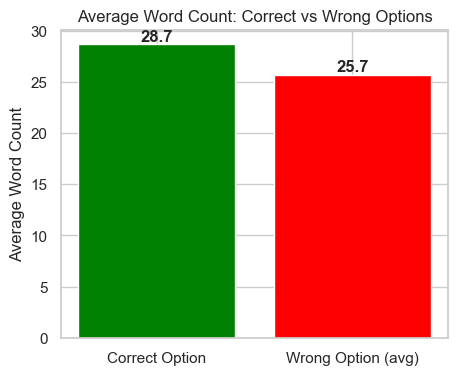

In [44]:
train['correct_option_len'] = train.apply(lambda row: len(str(row[row['answer']]).split()), axis=1)
train['wrong_option_len'] = train.apply(
    lambda row: np.mean([len(str(row[opt]).split()) for opt in options if opt != row['answer']]), axis=1)

avg_correct = train['correct_option_len'].mean()
avg_wrong = train['wrong_option_len'].mean()

plt.figure(figsize=(5, 4))
plt.bar(['Correct Option', 'Wrong Option (avg)'], [avg_correct, avg_wrong], color=['green', 'red'])
plt.title('Average Word Count: Correct vs Wrong Options')
plt.ylabel('Average Word Count')
for i, v in enumerate([avg_correct, avg_wrong]):
    plt.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
plt.show()

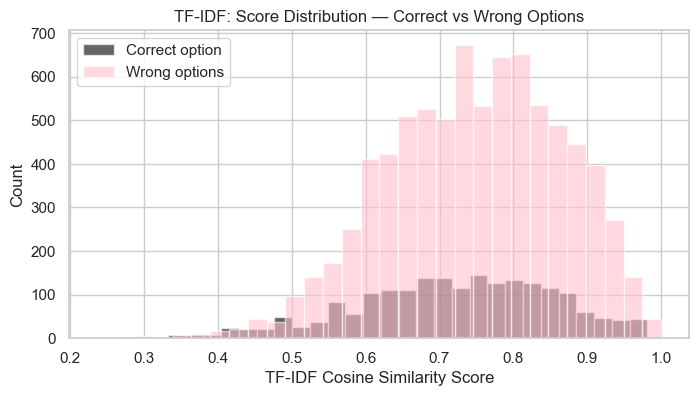

In [45]:
def get_all_scores(row):
    texts = [combine_prompt_option(row, opt) for opt in options]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    prompt_vec = vectorizer.transform([row['prompt']])
    scores = cosine_similarity(prompt_vec, tfidf_matrix).flatten()
    return scores, row['answer']

correct_scores = []
wrong_scores = []

for _, row in train.iterrows():
    scores, answer = get_all_scores(row)
    for i, opt in enumerate(options):
        if opt == answer:
            correct_scores.append(scores[i])
        else:
            wrong_scores.append(scores[i])

plt.figure(figsize=(8, 4))
plt.hist(correct_scores, bins=30, alpha=0.6, label='Correct option', color='black')
plt.hist(wrong_scores, bins=30, alpha=0.6, label='Wrong options', color='pink')
plt.xlabel('TF-IDF Cosine Similarity Score')
plt.ylabel('Count')
plt.title('TF-IDF: Score Distribution — Correct vs Wrong Options')
plt.legend()
plt.show()

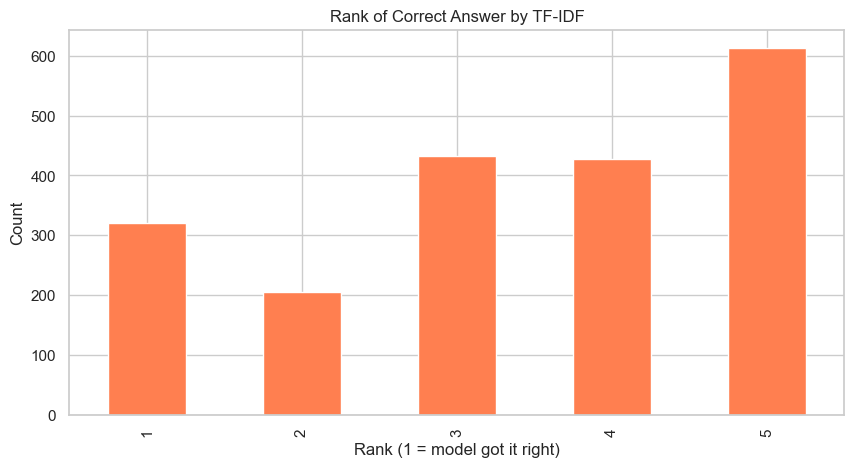

In [46]:
def get_rank_of_correct(row):
    texts = [combine_prompt_option(row, opt) for opt in options]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    prompt_vec = vectorizer.transform([row['prompt']])
    scores = cosine_similarity(prompt_vec, tfidf_matrix).flatten()
    ranked = scores.argsort()[::-1]
    correct_idx = options.index(row['answer'])
    return list(ranked).index(correct_idx) + 1  # rank 1-5

train['tfidf_rank'] = train.apply(get_rank_of_correct, axis=1)

train['tfidf_rank'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Rank of Correct Answer by TF-IDF')
plt.xlabel('Rank (1 = model got it right)')
plt.ylabel('Count')
plt.show()

In [49]:
!pip install sentence-transformers -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 687.52it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
model2 = SentenceTransformer('BAAI/bge-large-en-v1.5')

Loading weights: 100%|██████████| 391/391 [00:03<00:00, 116.05it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
def predict_top3_transformer(row):
    prompt_embedding = model2.encode(row['prompt'])
    option_embeddings = model2.encode([row[opt] for opt in options])
    scores = cosine_similarity([prompt_embedding], option_embeddings).flatten()
    top3_indices = scores.argsort()[::-1][:3]
    return ' '.join([options[i] for i in top3_indices])

In [58]:
test['Prediction'] = test.apply(predict_top3_transformer, axis=1)

submission = test[['id', 'Prediction']].copy()
submission.columns = ['ID', 'Prediction']
submission.to_csv('submission.csv', index=False)
print(submission.head())

   ID Prediction
0   1      B D A
1   2      E A C
2   3      A D C
3   4      E C A
4   5      C D E
